In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\new project\Customer Behavior & Churn Simulation Dataset\synthetic_customer_behavior_and_churn.csv")

In [63]:
df.head(5)

,customer_id,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
0,CUST_000001,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,medium,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,CUST_000002,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,medium,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,CUST_000003,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,CUST_000004,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,CUST_000005,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0


In [67]:
#to display all row and columns in the dataframe
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [69]:
#to ignore unnecessary warning messages 
import warnings
warnings.filterwarnings('ignore')

In [71]:
#to check the shape of the dataset 
print(f"No. of columns in this dataset = {df.shape[0]}")
print(f"No. of rows in this dataset = {df.shape[1]}")

No. of columns in this dataset = 15000
No. of rows in this dataset = 21


In [73]:
#to view exact columns names
df.columns

Index(['customer_id', 'signup_date', 'tenure_months', 'age', 'gender',
       'region', 'income_level', 'subscription_type', 'monthly_charges',
       'total_charges', 'usage_frequency', 'avg_session_duration_minutes',
       'number_of_logins_per_month', 'number_of_support_tickets',
       'satisfaction_score', 'payment_method', 'contract_type',
       'last_login_days_ago', 'promotional_response', 'discount_used',
       'churn'],
      dtype='object')

In [75]:
#to check all columns data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   15000 non-null  object 
 1   signup_date                   15000 non-null  object 
 2   tenure_months                 15000 non-null  int64  
 3   age                           15000 non-null  int64  
 4   gender                        15000 non-null  object 
 5   region                        15000 non-null  object 
 6   income_level                  15000 non-null  object 
 7   subscription_type             15000 non-null  object 
 8   monthly_charges               15000 non-null  float64
 9   total_charges                 15000 non-null  float64
 10  usage_frequency               15000 non-null  object 
 11  avg_session_duration_minutes  15000 non-null  float64
 12  number_of_logins_per_month    15000 non-null  int64  
 13  n

In [77]:
#to see random sample of 5 rows to undersatnd the variety
df.sample(5)

,customer_id,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
11486,CUST_011487,2024-12-05,1,18,Non-binary,Europe,medium,standard,78.06,78.61,high,67.8,29,5,5,Bank Transfer,monthly,82,yes,no,1
1853,CUST_001854,2023-02-22,22,53,Non-binary,North America,low,basic,33.79,684.94,low,14.3,7,1,1,Credit Card,yearly,44,no,yes,0
2021,CUST_002022,2023-02-19,22,45,Male,Asia Pacific,medium,standard,73.17,1542.69,medium,47.1,11,0,2,Bank Transfer,yearly,11,no,yes,0
2999,CUST_003000,2022-01-25,35,40,Female,Europe,low,basic,37.72,1404.50,low,20.4,11,8,2,Digital Wallet,yearly,66,yes,no,1
1882,CUST_001883,2023-10-12,14,27,Male,Latin America,low,basic,22.42,338.85,low,12.2,7,3,4,Credit Card,yearly,40,yes,yes,0


In [209]:
df.shape

(15000, 24)

In [79]:
#to check any missing values 
df.isnull().sum()

customer_id                     0
signup_date                     0
tenure_months                   0
age                             0
gender                          0
region                          0
income_level                    0
subscription_type               0
monthly_charges                 0
total_charges                   0
usage_frequency                 0
avg_session_duration_minutes    0
number_of_logins_per_month      0
number_of_support_tickets       0
satisfaction_score              0
payment_method                  0
contract_type                   0
last_login_days_ago             0
promotional_response            0
discount_used                   0
churn                           0
dtype: int64

In [81]:
#to check duplicate rows
df.duplicated().sum()

0

In [83]:
#loop through each column to find howmanytimes values are repeated
for col in df.columns :
    print(f"column:{col} = Duplicates: {df[col].duplicated().sum()}")

column:customer_id = Duplicates: 0
column:signup_date = Duplicates: 13904
column:tenure_months = Duplicates: 14965
column:age = Duplicates: 14937
column:gender = Duplicates: 14997
column:region = Duplicates: 14995
column:income_level = Duplicates: 14997
column:subscription_type = Duplicates: 14997
column:monthly_charges = Duplicates: 8443
column:total_charges = Duplicates: 497
column:usage_frequency = Duplicates: 14997
column:avg_session_duration_minutes = Duplicates: 13851
column:number_of_logins_per_month = Duplicates: 14951
column:number_of_support_tickets = Duplicates: 14988
column:satisfaction_score = Duplicates: 14995
column:payment_method = Duplicates: 14996
column:contract_type = Duplicates: 14998
column:last_login_days_ago = Duplicates: 14910
column:promotional_response = Duplicates: 14998
column:discount_used = Duplicates: 14998
column:churn = Duplicates: 14998


In [85]:
#to check data types of each column
print("\ndata types of each column:")
print(df.dtypes)


data types of each column:
customer_id                      object
signup_date                      object
tenure_months                     int64
age                               int64
gender                           object
region                           object
income_level                     object
subscription_type                object
monthly_charges                 float64
total_charges                   float64
usage_frequency                  object
avg_session_duration_minutes    float64
number_of_logins_per_month        int64
number_of_support_tickets         int64
satisfaction_score                int64
payment_method                   object
contract_type                    object
last_login_days_ago               int64
promotional_response             object
discount_used                    object
churn                             int64
dtype: object


In [87]:
#to identify categorical and constant columns 
unique_values = df.nunique()

print("\nUnique values count in each column:")
print(unique_values)


Unique values count in each column:
customer_id                     15000
signup_date                      1096
tenure_months                      35
age                                63
gender                              3
region                              5
income_level                        3
subscription_type                   3
monthly_charges                  6557
total_charges                   14503
usage_frequency                     3
avg_session_duration_minutes     1149
number_of_logins_per_month         49
number_of_support_tickets          12
satisfaction_score                  5
payment_method                      4
contract_type                       2
last_login_days_ago                90
promotional_response                2
discount_used                       2
churn                               2
dtype: int64


In [89]:
# to show mean,min,max,std etc
print("\nStatistical summary of numerical columns:")
print(df.describe())


Statistical summary of numerical columns:
       tenure_months           age  monthly_charges  total_charges  \
count   15000.000000  15000.000000     15000.000000   15000.000000   
mean       17.448467     41.646933        59.046174     978.208528   
std        10.304214     11.740994        32.996490     864.474724   
min         1.000000     18.000000        19.990000      16.500000   
25%         8.000000     33.000000        31.640000     351.145000   
50%        17.000000     42.000000        55.150000     735.260000   
75%        26.000000     50.000000        73.742500    1372.332500   
max        35.000000     80.000000       149.950000    5506.350000   

       avg_session_duration_minutes  number_of_logins_per_month  \
count                  15000.000000                15000.000000   
mean                      45.235633                   18.519600   
std                       29.244734                   12.335911   
min                        5.000000                    1.0

In [ ]:
                   TARGET VARIABLE (churn) Analysis

In [91]:
#to comfirms churn contains valid binary values
print("Unique values in churn column :")
print(df["churn"].unique())

Unique values in churn column :
[0 1]


In [93]:
#this counts customers in each churn category
churn_counts=df["churn"].value_counts()
print("\nChurn counts:")
print(churn_counts)


Churn counts:
churn
0    10217
1     4783
Name: count, dtype: int64


In [95]:
#to calculate percentage of each class
churn_percentage = df["churn"].value_counts(normalize=True)*100
print("\churn percentage:")
print(churn_percentage)

\churn percentage:
churn
0    68.113333
1    31.886667
Name: proportion, dtype: float64


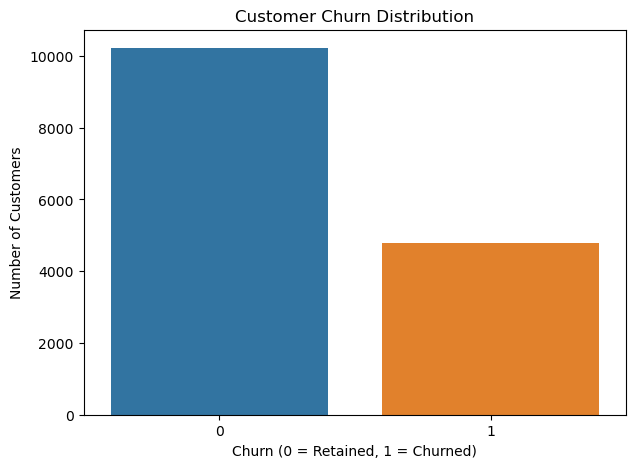

In [213]:
# This visualizes number of retained vs churned customers

plt.figure(figsize=(7,5))

# Create countplot
sns.countplot(x="churn", data=df)

# Add title and labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")

# Show plot
plt.show()

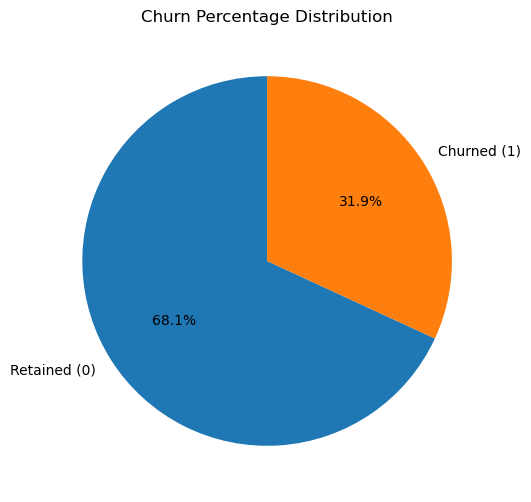

In [217]:
# This shows churn proportion visually

plt.figure(figsize=(6,6))

# Create churn counts
churn_counts = df["churn"].value_counts()

# Create pie chart
plt.pie(
    churn_counts,
    labels=["Retained (0)", "Churned (1)"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Churn Percentage Distribution")
plt.show()

In [221]:
# This creates a summary table for business understanding

# Create churn counts (sorted to keep 0 then 1)
churn_counts = df["churn"].value_counts().sort_index()

# Calculate percentage
churn_percentage = (churn_counts / churn_counts.sum()) * 100

# Create summary table
churn_summary = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage (%)": churn_percentage.round(2)
})

print("\nChurn Summary Table:")
print(churn_summary)


Churn Summary Table:
       Customer Count  Percentage (%)
churn                                
0               10217           68.11
1                4783           31.89


In [ ]:
                   #Feature Engineering

In [99]:
#convert Signup_date to Datetime
df["signup_date"] = pd.to_datetime(df["signup_date"],errors= "coerce")

#create tenure feature
current_date = pd.to_datetime("today")
df["tenure_days"] = (current_date - df["signup_date"]).dt.days

#Create tenure in Months
df["tenure_months"]=df["tenure_days"] // 30

#Verify new features
print(df[["signup_date","tenure_days","tenure_months"]].head())

  signup_date  tenure_days  tenure_months
0  2022-08-17         1289             42
1  2022-02-21         1466             48
2  2023-07-18          954             31
3  2023-05-17         1016             33
4  2023-04-03         1060             35


In [101]:
#Tenure shows how long customer using service

#Get today's date
current_date=pd.to_datetime("today")

#Calculate tenure in days
df["tenure_days"]=(current_date - df["signup_date"]).dt.days

#show sample values
print("Sample tenure_days:")
print(df["tenure_days"].head())

Sample tenure_days:
0    1289
1    1466
2     954
3    1016
4    1060
Name: tenure_days, dtype: int64


In [103]:
#for easy business understanding converts tenure from days to months

df["tenure_months"] = df["tenure_days"] // 30

#showsample values
print("\nSample tenure_months:")
print(df["tenure_months"].head())


Sample tenure_months:
0    42
1    48
2    31
3    33
4    35
Name: tenure_months, dtype: int64


In [105]:
#Convert important columns to numeric

numeric_columns= [
    "total_charges",
    "usage_frequency",
    "avg_session_duration_minutes",
    "tenure_months",
    "last_login_days_ago",
    "number_of_support_tickets",
    "monthly_charges"
]

for col in numeric_columns:
    df[col]=pd.to_numeric(df[col], errors = "coerce")
print("Columns converted to numeric successfully")

Columns converted to numeric successfully


In [107]:
#Feature Engineering

#average monthly spend
df["avg_monthly_spend"] = df["total_charges"] / (df["tenure_months"] + 1)

#Usage intensity
df["usage_intensity"] = (
    df["usage_frequency"] * df["avg_session_duration_minutes"]
)


#Inactive customer flag
df["inactive_customer"]=(
    df["last_login_days_ago"] > df["last_login_days_ago"].median()
)


#verify
print(df[["avg_monthly_spend",
         "usage_intensity",
         "inactive_customer"]].head())

   avg_monthly_spend  usage_intensity  inactive_customer
0          24.047907              NaN              False
1          42.145102              NaN              False
2          39.003437              NaN               True
3          45.308824              NaN              False
4          32.393611              NaN               True


In [109]:
#create avg_monthly_spend feature 

#Convert to numeric first
df["total_charges"]= pd.to_numeric(df["total_charges"], errors = "coerce")
df["tenure_months"]= pd.to_numeric(df["tenure_months"], errors = "coerce")

#create average monthly spend feature
df["avg_monthly_spend"] = df["total_charges"] / (df["tenure_months"]+1)

#Show result
print(df[["total_charges","tenure_months","avg_monthly_spend"]].head())


   total_charges  tenure_months  avg_monthly_spend
0        1034.06             42          24.047907
1        2065.11             48          42.145102
2        1248.11             31          39.003437
3        1540.50             33          45.308824
4        1166.17             35          32.393611


In [111]:
#create usage_intensity feature


#Convert columns to numeric first

df["usage_frequency"] = pd.to_numeric(df["usage_frequency"],errors ="coerce")
df["avg_session_duration_minutes"] = pd.to_numeric (df["avg_session_duration_minutes"], errors = "coerce"
)


#create usage intensity feature

df["usage_intensity"] = (
    df["usage_frequency"]*df["avg_session_duration_minutes"]
)

#show result
print(df[["usage_frequency","avg_session_duration_minutes","usage_intensity"]].head())

   usage_frequency  avg_session_duration_minutes  usage_intensity
0              NaN                          55.3              NaN
1              NaN                          25.7              NaN
2              NaN                           9.0              NaN
3              NaN                          99.4              NaN
4              NaN                           8.4              NaN


In [113]:
#This groups customers into lifecycle stages
df["tenure_group"] =pd.cut(
    df["tenure_months"],
    bins=[0,6,12,24,60],
    labels=["New","Early","Mid","Loyal"]
)

print("\nSample tenure_group :")
print(df["tenure_group"].head())


Sample tenure_group :
0    Loyal
1    Loyal
2    Loyal
3    Loyal
4    Loyal
Name: tenure_group, dtype: category
Categories (4, object): ['New' < 'Early' < 'Mid' < 'Loyal']


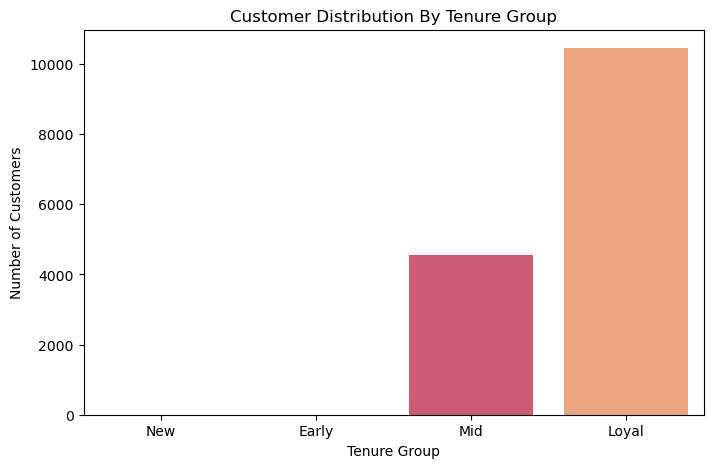

In [115]:
#to show how customers are distributed across life cycle stages


plt.figure(figsize=(8,5))

sns.countplot(x="tenure_group",data=df,palette="magma")

#add title and labels
plt.title("Customer Distribution By Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.show()

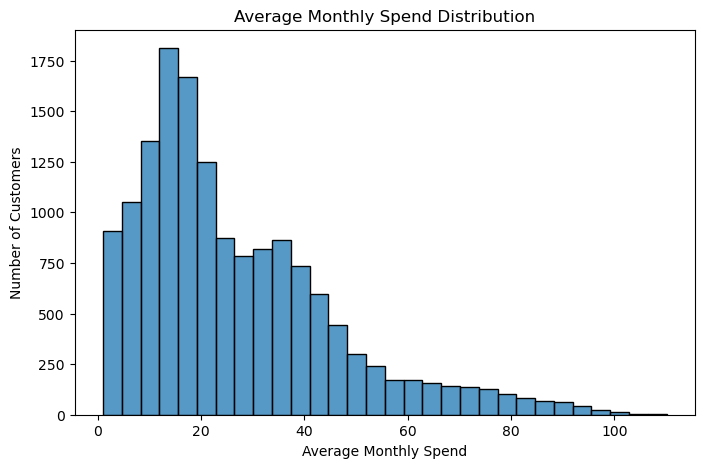

In [117]:
#showing spending behavior distribution

plt.figure(figsize=(8,5))

sns.histplot(df["avg_monthly_spend"],bins=30)

#add labels and title
plt.title("Average Monthly Spend Distribution")
plt.xlabel("Average Monthly Spend")
plt.ylabel("Number of Customers")

plt.show()

In [119]:
#show first 5 rowsof new features
new_features= [
    "tenure_days",
    "tenure_months",
    "avg_monthly_spend",
    "usage_intensity",
    "tenure_group"
]

print("\nNew Feature Sample:")
print(df[new_features].head())


New Feature Sample:
   tenure_days  tenure_months  avg_monthly_spend  usage_intensity tenure_group
0         1289             42          24.047907              NaN        Loyal
1         1466             48          42.145102              NaN        Loyal
2          954             31          39.003437              NaN        Loyal
3         1016             33          45.308824              NaN        Loyal
4         1060             35          32.393611              NaN        Loyal


In [ ]:
                           Customer Demographics Analysis

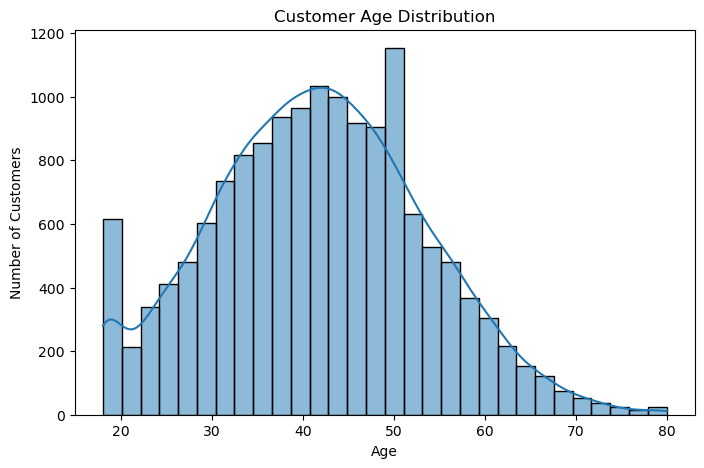

In [121]:
#shows how customer ages are destributed

plt.figure(figsize=(8,5))

#create histogram for age distribution
sns.histplot(df["age"], bins=30,kde=True)

#add titles and labels
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

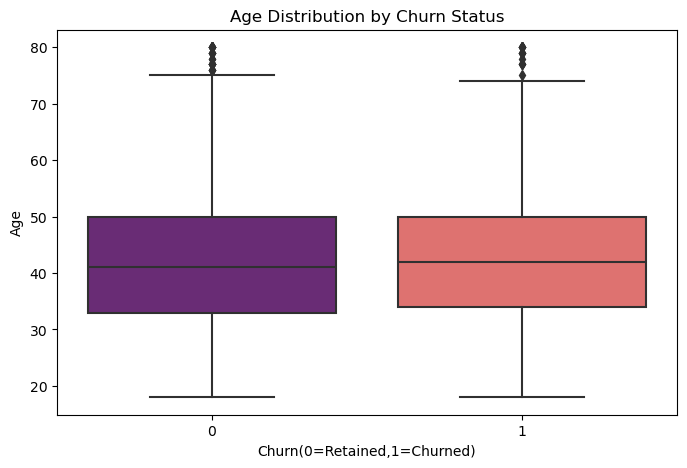

In [123]:
#Thisshows whether churn differs by age

plt.figure(figsize=(8,5))

#Boxplot compares age distribution between churned and retained customers

sns.boxplot(x="churn",y="age",data=df,palette="magma")

#add title and labels

plt.title("Age Distribution by Churn Status")
plt.xlabel("Churn(0=Retained,1=Churned)")
plt.ylabel("Age")

plt.show()

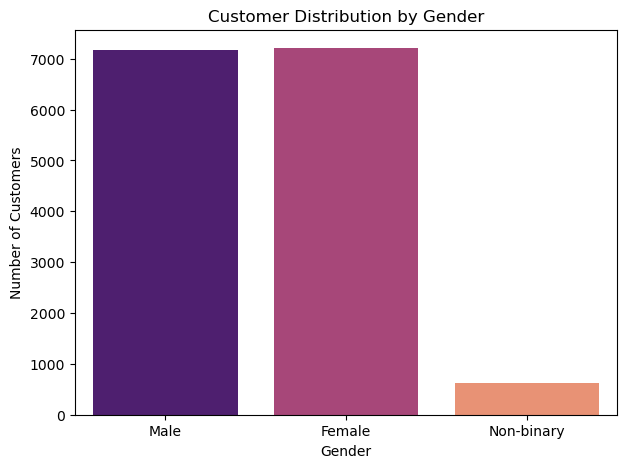

In [125]:
#Shows the number of male and female customers

plt.figure(figsize=(7,5))

sns.countplot(x="gender", data = df, palette="magma")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()



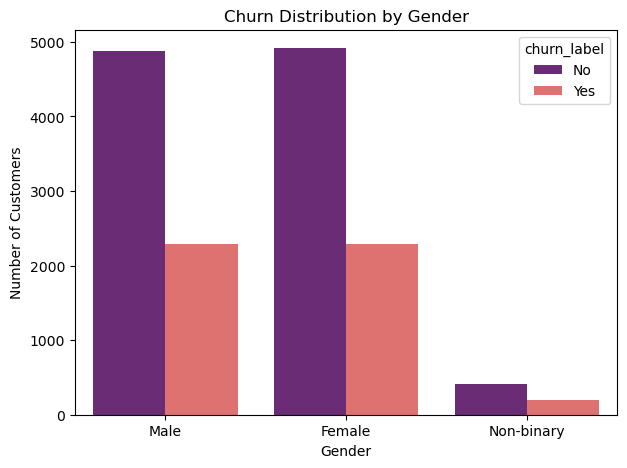

In [144]:
#Shows churn comparision between genders

df["churn_label"] = df["churn"].map({0: "No", 1: "Yes"})

plt.figure(figsize=(7,5))

sns.countplot(
    x="gender",
    hue="churn_label",
    data=df,
    palette="magma"
)

plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

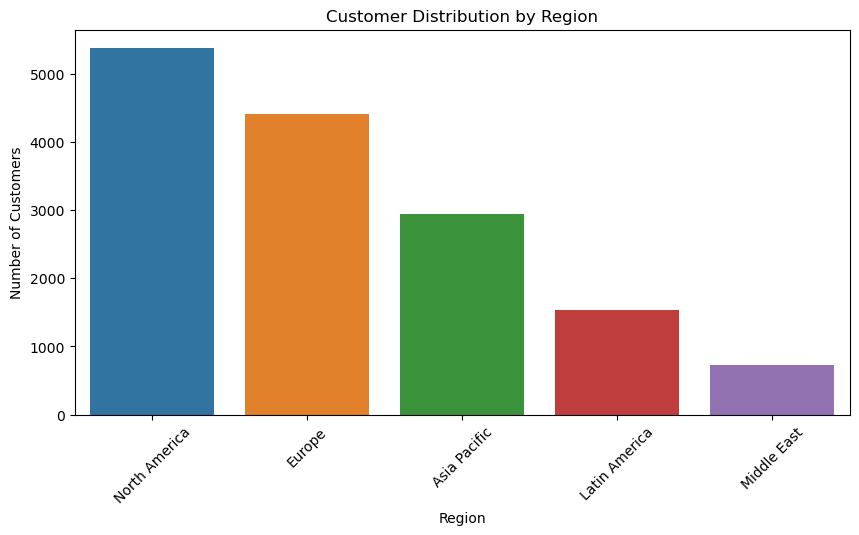

In [140]:
#shows customer distribution across regions

plt.figure(figsize=(10,5))

sns.countplot(x="region",data=df)

plt.title("Customer Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

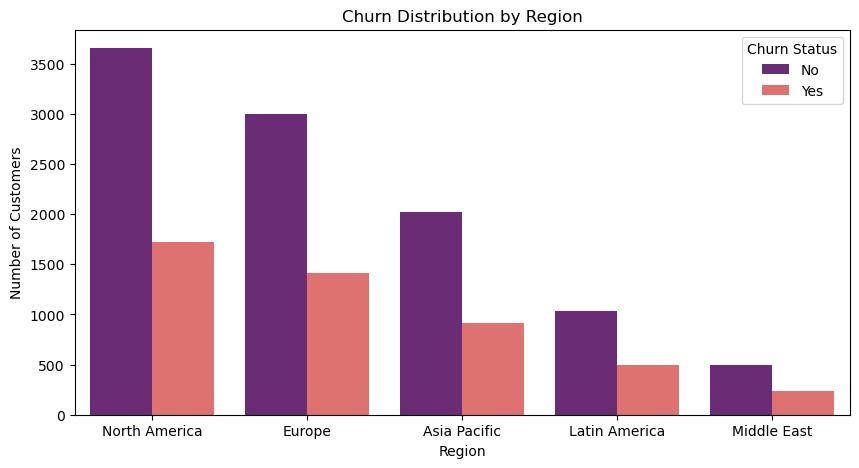

In [154]:
# This shows churn comparison across regions


# Create a separate string label for churn
df["churn_label"] = df["churn"].map({0: "No", 1: "Yes"})

# If churn contains other numeric codes, convert them to strings:
df["churn_label"] = df["churn_label"].astype(str)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    x="region",
    hue="churn_label",   # use the new categorical column here
    data=df,
    palette="magma"
)

plt.title("Churn Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status")   # optional, for a clearer legend
plt.show()

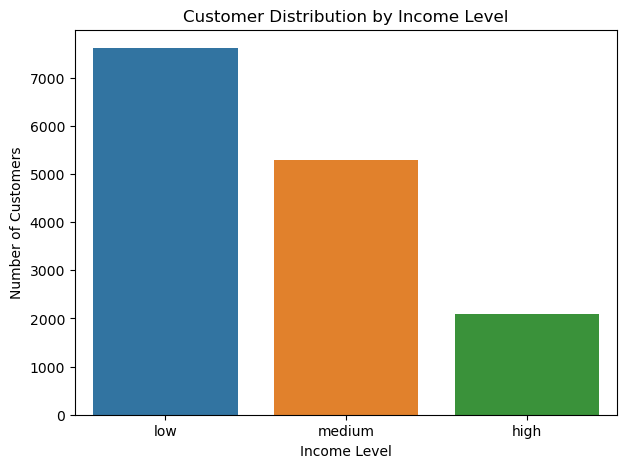

In [156]:
#shows how customers are distributed by income level

plt.figure(figsize=(7,5))

sns.countplot(x="income_level",data = df)

plt.title("Customer Distribution by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Number of Customers")

plt.show()

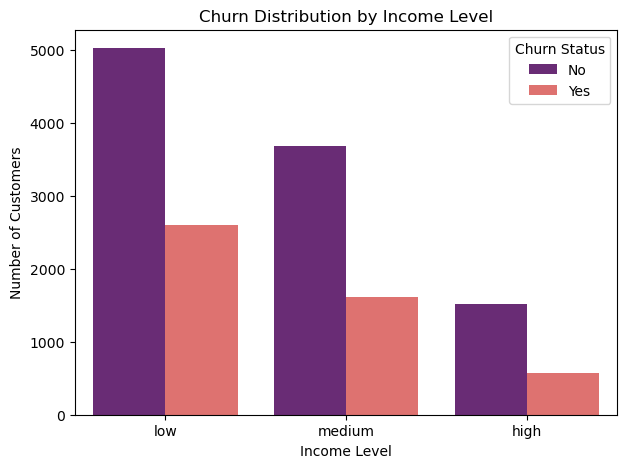

In [9]:
#shows churn comparison across income levels


import matplotlib.pyplot as plt
import seaborn as sns

df["churn_label"] = df["churn"].map({0:"No", 1:"Yes"}).astype(str)

plt.figure(figsize=(7,5))
sns.countplot(
    x="income_level",
    hue="churn_label",
    data=df,
    palette="magma"
)

plt.title("Churn Distribution by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Number of Customers")
plt.legend(title="Churn Status")

plt.show()

In [13]:
#summary tables for demographics


#Age summary
print("\nAge Summary:")
print(df["age"].describe())

#Gender Count
print("\nGender Distribution:")
print(df["gender"].value_counts())

#Region Count
print("\nRegion Distribution:")
print(df["region"].value_counts())


#Income level Count
print("\nIncomeLevel Distribution:")
print(df["income_level"].value_counts())


Age Summary:
count    15000.000000
mean        41.646933
std         11.740994
min         18.000000
25%         33.000000
50%         42.000000
75%         50.000000
max         80.000000
Name: age, dtype: float64

Gender Distribution:
gender
Female        7210
Male          7171
Non-binary     619
Name: count, dtype: int64

Region Distribution:
region
North America    5377
Europe           4414
Asia Pacific     2938
Latin America    1537
Middle East       734
Name: count, dtype: int64

IncomeLevel Distribution:
income_level
low       7614
medium    5288
high      2098
Name: count, dtype: int64


In [ ]:
                       #CUSTOMER BEHAVIOR ANALYSIS

In [223]:
#define behavior columns

behavior_columns=[
    "usage_frequency",
    "average_session_duration",
    "last_login_days",
    "support_tickets",
    "satisfaction_score"
]

In [35]:
#define correct behavior columns

behavior_columns=[
    "usage_frequency",
    "avg_session_duration_minutes",
    "number_of_support_tickets",
    "last_login_days_ago",
    "satisfaction_score"
]

#show statistical summary
print("Overall Behavior Summary")
print(df[behavior_columns].describe())

Overall Behavior Summary
       avg_session_duration_minutes  number_of_support_tickets  \
count                  15000.000000               15000.000000   
mean                      45.235633                   2.927133   
std                       29.244734                   2.609012   
min                        5.000000                   0.000000   
25%                       21.900000                   1.000000   
50%                       40.500000                   2.000000   
75%                       58.500000                   4.000000   
max                      119.900000                  11.000000   

       last_login_days_ago  satisfaction_score  
count         15000.000000         15000.00000  
mean             21.748533             3.38440  
std              22.282570             1.24951  
min               0.000000             1.00000  
25%               5.000000             3.00000  
50%              13.000000             4.00000  
75%              32.000000           

In [41]:
#Compare Behavior by Churn

for col in behavior_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# now compute average behavior by churn
behavior_churn_summary = df.groupby("churn")[behavior_columns].mean(numeric_only=True)

print("\nAverage Behavior by Churn:")
print(behavior_churn_summary)


Average Behavior by Churn:
       usage_frequency  avg_session_duration_minutes  \
churn                                                  
0                  NaN                     48.589508   
1                  NaN                     38.071399   

       number_of_support_tickets  last_login_days_ago  satisfaction_score  
churn                                                                      
0                       1.919154            12.546540            3.878144  
1                       5.080284            41.404976            2.329709  


In [43]:
#shows average behavior of retained vs churned customers

behavior_churn_summary =  df.groupby("churn")[behavior_columns].mean()

print("\nAverage Behavior by Churn:")
print(behavior_churn_summary)


Average Behavior by Churn:
       usage_frequency  avg_session_duration_minutes  \
churn                                                  
0                  NaN                     48.589508   
1                  NaN                     38.071399   

       number_of_support_tickets  last_login_days_ago  satisfaction_score  
churn                                                                      
0                       1.919154            12.546540            3.878144  
1                       5.080284            41.404976            2.329709  


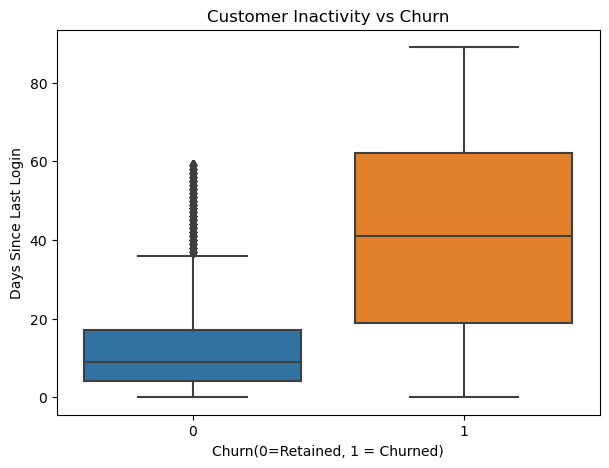

In [55]:
#Customer Inactivity vs Churn

#Clean data before plotting

df_plot = df.replace([np.inf,-np.inf],np.nan)

df_plot = df_plot.dropna(subset=["churn","last_login_days_ago"])

#create boxplot

plt.figure(figsize=(7,5))

sns.boxplot(x="churn",y="last_login_days_ago",data=df_plot)

plt.title("Customer Inactivity vs Churn")
plt.xlabel("Churn(0=Retained, 1 = Churned)")
plt.ylabel("Days Since Last Login")

plt.show()

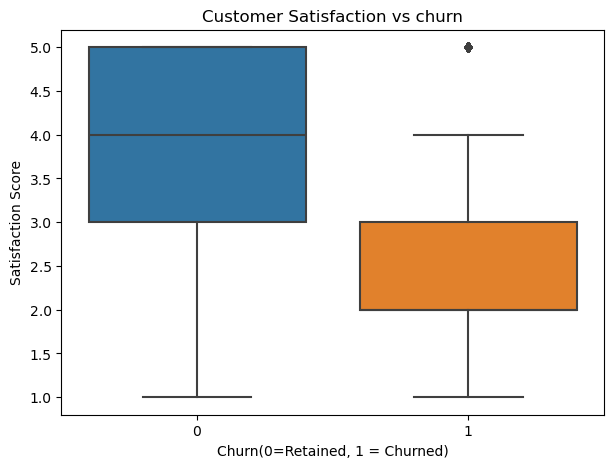

In [57]:
#satisfaction score vs churn

#shows wheather dissatisfied customers churn more

plt.figure(figsize=(7,5))
sns.boxplot(x="churn",y="satisfaction_score",data = df)

plt.title("Customer Satisfaction vs churn")
plt.xlabel("Churn(0=Retained, 1 = Churned)")
plt.ylabel("Satisfaction Score")

plt.show()

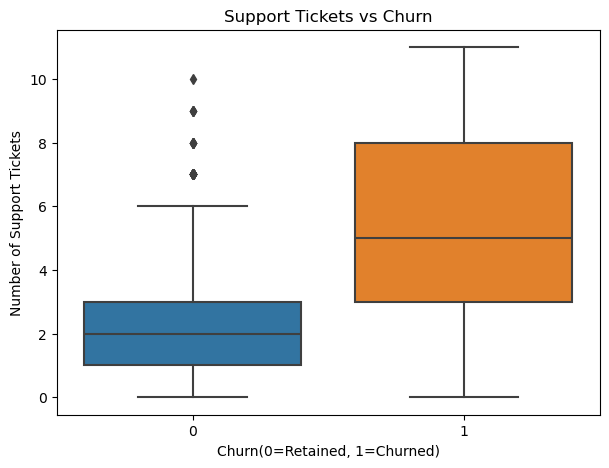

In [61]:
#support tickets vs Churn (Correct)

#clean data before plotting

df_plot=df.replace([np.inf,-np.inf],np.nan)
df_plot=df_plot.dropna(subset=["churn","number_of_support_tickets"])

#Create boxplot

plt.figure(figsize=(7,5))

sns.boxplot(x="churn",y="number_of_support_tickets",data=df_plot)


plt.title("Support Tickets vs Churn")
plt.xlabel("Churn(0=Retained, 1=Churned)")
plt.ylabel("Number of Support Tickets")

plt.show()

In [ ]:
#CONTRACT, BILLING & SERVICE INSIGHTS

In [63]:
#define billing and service columns
billing_columns=[
    "subscription_type",
    "payment_method",
    "monthly_charges",
    "total_spent",
    "discount_usage",
    "promotional_response"

]

In [65]:
#this shows number of customers in each subscription plan

print("subscription Type Distribution:")
print(df["subscription_type"].value_counts())

subscription Type Distribution:
subscription_type
basic       6428
standard    6107
premium     2465
Name: count, dtype: int64


In [67]:
#This shows churn rate by subscription type

subscription_churn = pd.crosstab(df["subscription_type"],df["churn"])

print("\nSubscription Type vs Churn:")
print(subscription_churn)


Subscription Type vs Churn:
churn                 0     1
subscription_type            
basic              4134  2294
premium            1965   500
standard           4118  1989


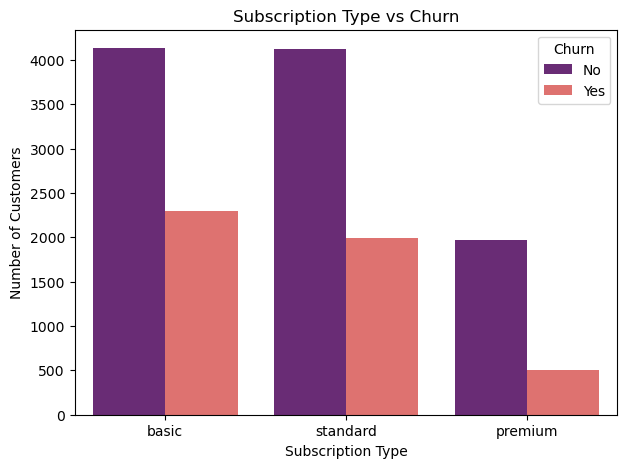

In [71]:
#visualization


# Make sure churn is categorical text
df["churn_label"] = df["churn"].map({0: "No", 1: "Yes"}).astype(str)

plt.figure(figsize=(7,5))

sns.countplot(
    x="subscription_type",
    hue="churn_label",   # <-- use the string column here
    data=df,
    palette="magma"
)

plt.title("Subscription Type vs Churn")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")
plt.show()

In [73]:
#shows churn pattern by payment method

payment_churn=pd.crosstab(df["payment_method"],df["churn"])

print("\nPayement Method vs Churn:")
print(payment_churn)


Payement Method vs Churn:
churn              0     1
payment_method            
Bank Transfer   1493   734
Credit Card     5057  2360
Digital Wallet  1011   457
PayPal          2656  1232


AttributeError: 'numpy.int64' object has no attribute 'startswith'

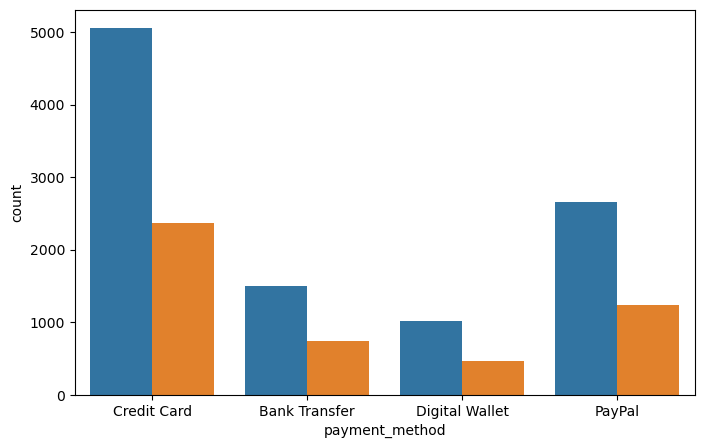

In [75]:
#visualization

plt.figure(figsize=(8,5))

sns.countplot(x="payment_method",hue="churn",data =df)

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

In [77]:
#shows monthly charges summary by churn

print("\nMonthly Charge Summary by Churn:")
print(df.groupby("churn")["monthly_charges"].describe())


Monthly Charge Summary by Churn:
         count       mean        std    min    25%    50%     75%     max
churn                                                                    
0      10217.0  61.469184  34.257263  19.99  32.46  57.14  75.670  149.95
1       4783.0  53.870366  29.470553  20.00  30.36  51.57  69.345  149.89


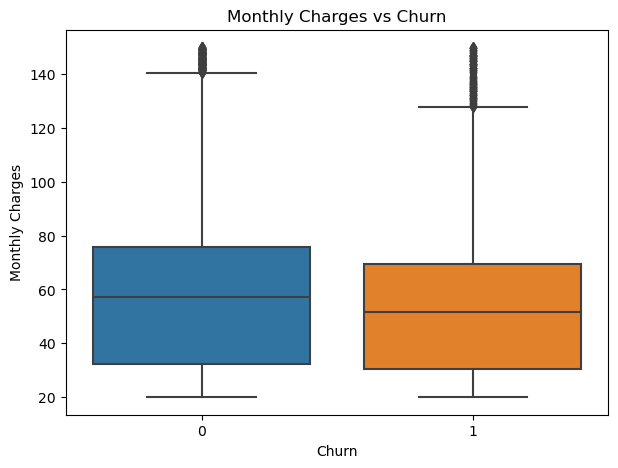

In [79]:
#visualization

plt.figure(figsize=(7,5))

sns.boxplot(x="churn",y="monthly_charges",data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [85]:
#Total charges summary by churn(correct)

#Convert tonumeric(safe practice)

df["total_charges"]=pd.to_numeric(df["total_charges"],errors="coerce")


#show summary statistics grouped by churn

print("\nTotal Charges Summary by Churn:")

print(df.groupby("churn")["total_charges"].describe())


Total Charges Summary by Churn:
         count         mean         std    min      25%     50%      75%  \
churn                                                                      
0      10217.0  1112.202036  902.038958  16.95  466.110  855.76  1546.57   
1       4783.0   691.984052  696.712290  16.50  194.245  474.80   934.53   

           max  
churn           
0      5506.35  
1      5255.64  


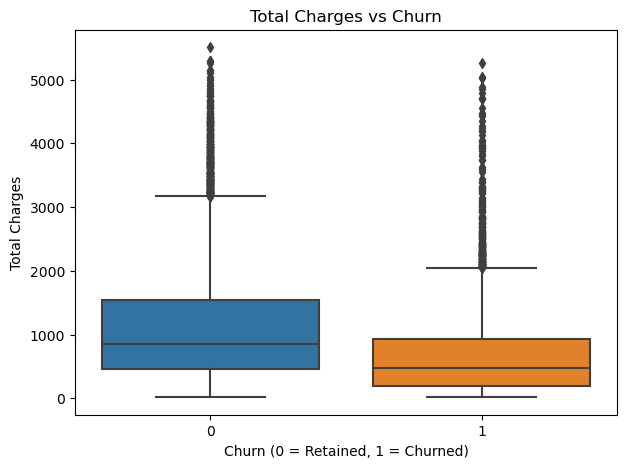

In [93]:
#clean data before plotting

df_plot=df.replace([np.inf,-np.inf],np.nan)

df_plot=df_plot.dropna(subset=["churn","total_charges"])


#create boxplot
plt.figure(figsize=(7,5))

sns.boxplot(x="churn", y="total_charges", data=df_plot)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Total Charges")

plt.show()

In [95]:
#discount Used vs Churn (Correct)

#Create churn comparision table

discount_churn = pd.crosstab(df["discount_used"],df["churn"])

print("\nDiscount Used vs Churn:")
print(discount_churn)


Discount Used vs Churn:
churn             0     1
discount_used            
no             4993  2437
yes            5224  2346


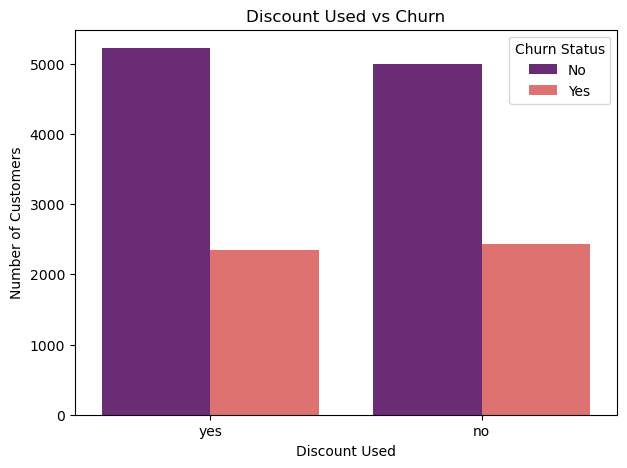

In [99]:
#clean data before plotting

df_plot=df.replace([np.inf,-np.inf],np.nan)

df_plot=df_plot.dropna(subset=["discount_used","churn"])

#create countplot

plt.figure(figsize=(7,5))
sns.countplot(
    x="discount_used",
    hue="churn_label",   # use string labels
    data=df,
    palette="magma"
)

plt.title("Discount Used vs Churn")
plt.xlabel("Discount Used")
plt.ylabel("Number of Customers")
plt.legend(title="Churn Status")
plt.show()

In [101]:
#shows wheather promotions improve retention

promo_churn=pd.crosstab(df["promotional_response"],df["churn"])

print("\nPromotional Response vs Churn:")
print(promo_churn)


Promotional Response vs Churn:
churn                    0     1
promotional_response            
no                    4010  2503
yes                   6207  2280


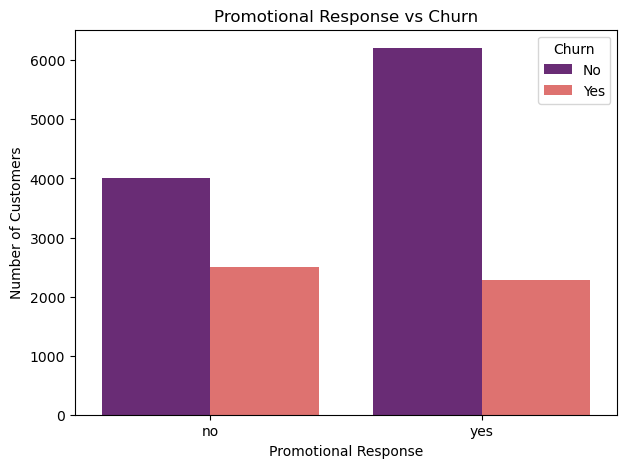

In [105]:
#visualization

plt.figure(figsize=(7,5))

sns.countplot(
    x="promotional_response",
    hue="churn_label",  # use the string column
    data=df,
    palette="magma"
)

plt.title("Promotional Response vs Churn")
plt.xlabel("Promotional Response")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

In [ ]:
                           #UNIVARIATE DISTRIBUTION ANALYSIS

In [113]:
#Correct NumericalColumns List

numerical_columns =[
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges",
    "usage_frequency",
    "avg_session_duration_minutes",
    "number_of_logins_per_month",
    "number_of_support_tickets",
    "satisfaction_score",
    "last_login_days_ago",
    "tenure_months"
]
    

In [111]:
df.columns

Index(['customer_id', 'signup_date', 'tenure_months', 'age', 'gender',
       'region', 'income_level', 'subscription_type', 'monthly_charges',
       'total_charges', 'usage_frequency', 'avg_session_duration_minutes',
       'number_of_logins_per_month', 'number_of_support_tickets',
       'satisfaction_score', 'payment_method', 'contract_type',
       'last_login_days_ago', 'promotional_response', 'discount_used', 'churn',
       'churn_label'],
      dtype='object')

In [115]:
#shows count,mean,std,min,max and quartiles
print("Statistical Summary of Numerical Features:")
print(df[numerical_columns].describe())

Statistical Summary of Numerical Features:
       tenure_months           age  monthly_charges  total_charges  \
count   15000.000000  15000.000000     15000.000000   15000.000000   
mean       17.448467     41.646933        59.046174     978.208528   
std        10.304214     11.740994        32.996490     864.474724   
min         1.000000     18.000000        19.990000      16.500000   
25%         8.000000     33.000000        31.640000     351.145000   
50%        17.000000     42.000000        55.150000     735.260000   
75%        26.000000     50.000000        73.742500    1372.332500   
max        35.000000     80.000000       149.950000    5506.350000   

       usage_frequency  avg_session_duration_minutes  \
count              0.0                  15000.000000   
mean               NaN                     45.235633   
std                NaN                     29.244734   
min                NaN                      5.000000   
25%                NaN                     21.

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


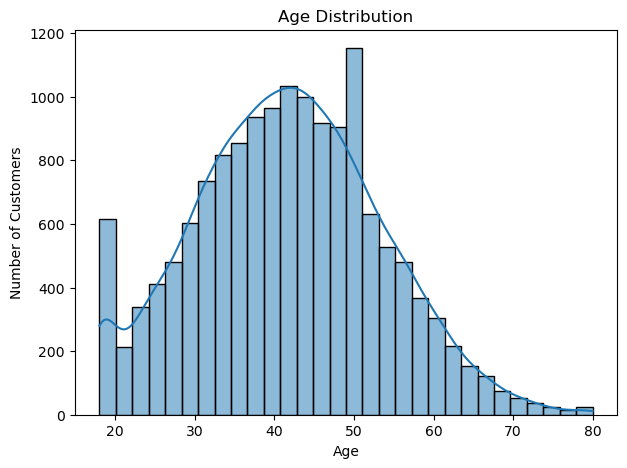

In [117]:
#Age Distribution

plt.figure(figsize=(7,5))

sns.histplot(df["age"],bins=30,kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


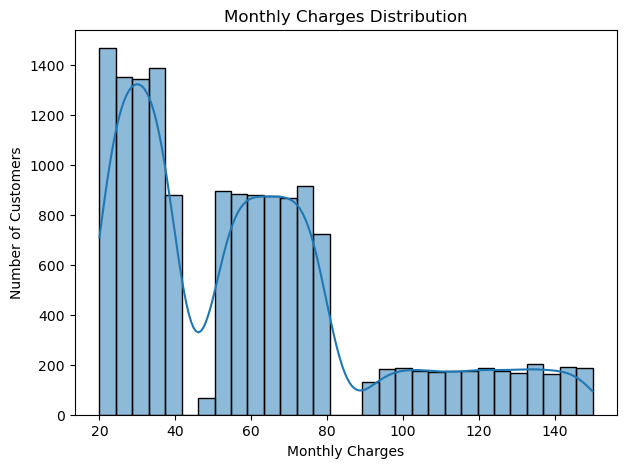

In [119]:
#Monthly Charges Distribution

plt.figure(figsize=(7,5))

sns.histplot(df["monthly_charges"],bins=30,kde=True)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


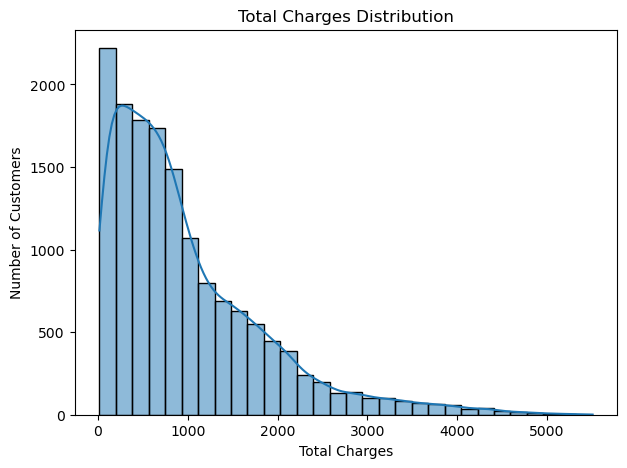

In [123]:
#Total Spent Distribution

#Total Charges Distribution (Correct)

#Convert tonumeric (safe practice)

df["total_charges"]= pd.to_numeric(df["total_charges"], errors ="coerce")

#clean missing values

df_plot = df.dropna(subset =["total_charges"])

#Create histogram

plt.figure(figsize=(7,5))

sns.histplot(df_plot["total_charges"],bins=30,kde=True)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


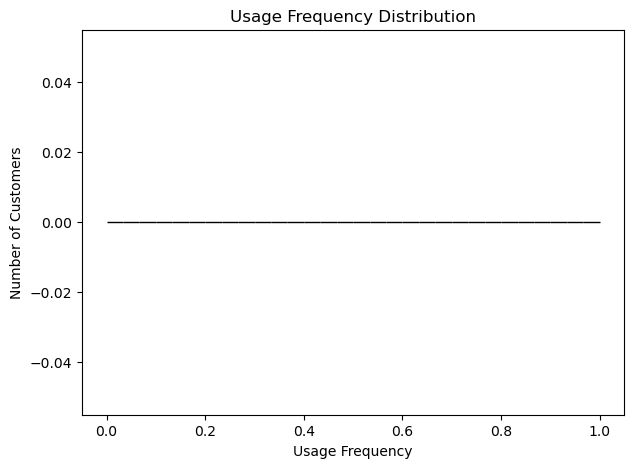

In [125]:
#Usage Frequency Distribution

plt.figure(figsize=(7,5))

sns.histplot(df["usage_frequency"],bins=30,kde=True)

plt.title("Usage Frequency Distribution")
plt.xlabel("Usage Frequency")
plt.ylabel("Number of Customers")

plt.show()

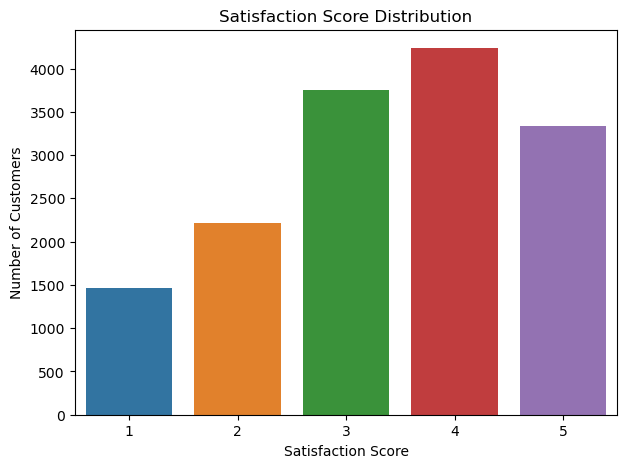

In [127]:
#Satisfaction Score Distribution

#Satisfaction score is categoricalnumeric (1 to 5)

plt.figure(figsize=(7,5))

sns.countplot(x="satisfaction_score",data=df)

plt.title("Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
#FEATURE_WISE CHURN IMPACT ANALYSIS

In [139]:
#define numerical  features(Correct for your dataset)

numerical_features = [
    "tenure_months",
    "age",
    "monthly_charges",
    "total_charges",
    "usage_frequency",
    "avg_session_duration_minutes",
    "number_of_logins_per_month",
    "number_of_support_tickets",
    "satisfaction_score",
    "last_login_days_ago",
    "tenure_months"
]

In [141]:
#Numerical featureimpact on churn

#Compare average values between retained and churned customers

numerical_impact = df.groupby("churn")[numerical_features].mean()

print("Numerical Feature Impact on Churn:")
print(numerical_impact)

Numerical Feature Impact on Churn:
       tenure_months        age  monthly_charges  total_charges  \
churn                                                             
0          19.133601  41.591563        61.469184    1112.202036   
1          13.848840  41.765210        53.870366     691.984052   

       usage_frequency  avg_session_duration_minutes  \
churn                                                  
0                  NaN                     48.589508   
1                  NaN                     38.071399   

       number_of_logins_per_month  number_of_support_tickets  \
churn                                                          
0                       19.871391                   1.919154   
1                       15.632030                   5.080284   

       satisfaction_score  last_login_days_ago  tenure_months  
churn                                                          
0                3.878144            12.546540      19.133601  
1                2.329

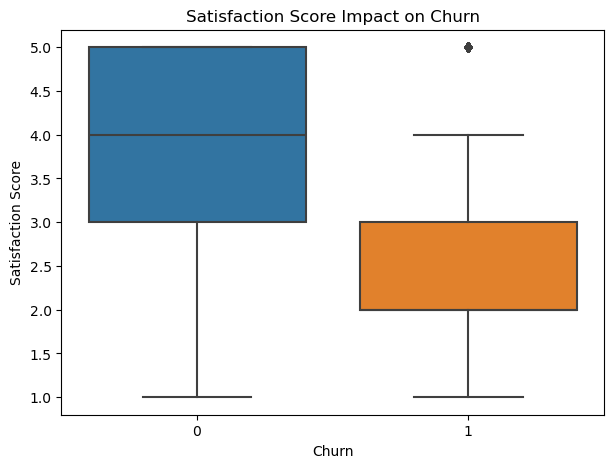

In [143]:
#satisfaction Score Impact (IMP)

plt.figure(figsize=(7,5))

sns.boxplot(x="churn",y="satisfaction_score",data=df)

plt.title("Satisfaction Score Impact on Churn")
plt.xlabel("Churn")
plt.ylabel("Satisfaction Score")

plt.show()

In [159]:
#Usage Frequency Impact

# Clean data before boxplot (Professional Fix)


import numpy as np

# Replace infinite values with NaN

df_clean = df.replace([np.inf, -np.inf], np.nan)


# Remove rows where required columns have missing values

df_clean = df_clean.dropna(subset=["churn", "usage_frequency"])


# Convert to numeric again (extra safety)

df_clean["usage_frequency"] = pd.to_numeric(df_clean["usage_frequency"], errors="coerce")

df_clean["churn"] = pd.to_numeric(df_clean["churn"], errors="coerce")



###### Now create boxplot safely


plt.figure(figsize=(7,5))

sns.boxplot(x="churn", y="usage_frequency", data=df_clean)

plt.title("Usage Frequency Impact on Churn")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Usage Frequency")

plt.show()

ValueError: min() arg is an empty sequence

<Figure size 700x500 with 0 Axes>

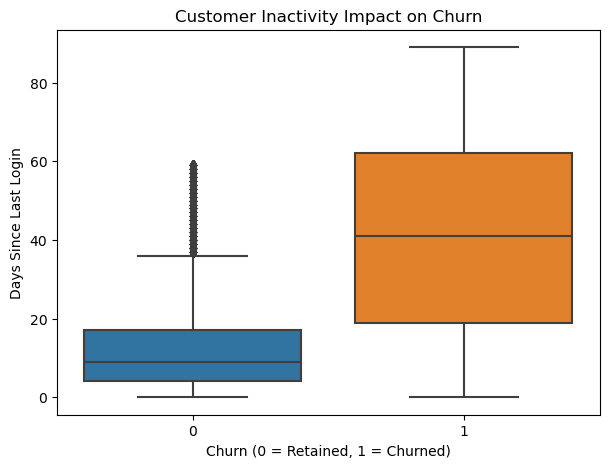

In [161]:
# Customer Inactivity Impact on Churn (Correct)


# Clean data before plotting

df_clean = df.replace([np.inf, -np.inf], np.nan)

df_clean = df_clean.dropna(subset=["churn", "last_login_days_ago"])


# Create boxplot

plt.figure(figsize=(7,5))

sns.boxplot(x="churn", y="last_login_days_ago", data=df_clean)

plt.title("Customer Inactivity Impact on Churn")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Days Since Last Login")

plt.show()

In [163]:
#Categorical Feature Impact (Subscription Type)

# Table summary
subscription_impact = pd.crosstab(df["subscription_type"], df["churn"])

print("\nSubscription Type Impact on Churn:")
print(subscription_impact)


Subscription Type Impact on Churn:
churn                 0     1
subscription_type            
basic              4134  2294
premium            1965   500
standard           4118  1989


AttributeError: 'numpy.int64' object has no attribute 'startswith'

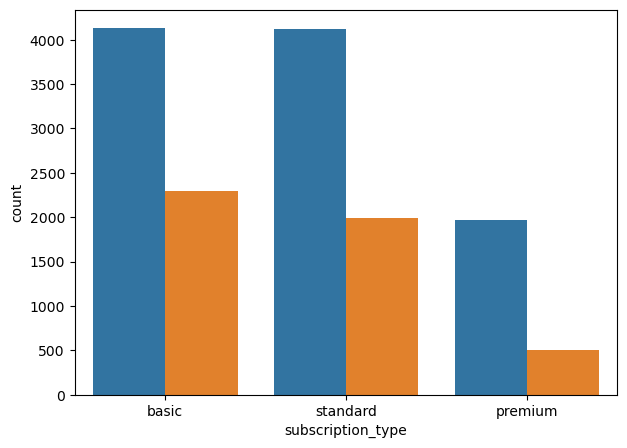

In [165]:
# Visualization (important billing factor)
plt.figure(figsize=(7,5))

sns.countplot(x="subscription_type", hue="churn", data=df)

plt.title("Subscription Type Impact on Churn")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
#Multivariate Analysis & Correlation

Correlation Matrix:
                                   age  tenure_months  monthly_charges  \
age                           1.000000      -0.009194         0.028310   
tenure_months                -0.009194       1.000000        -0.000998   
monthly_charges               0.028310      -0.000998         1.000000   
total_charges                 0.011781       0.662814         0.634164   
usage_frequency                    NaN            NaN              NaN   
avg_session_duration_minutes  0.007470      -0.012988         0.304315   
number_of_logins_per_month    0.008811      -0.010783         0.308904   
number_of_support_tickets    -0.002159      -0.131862        -0.058143   
satisfaction_score           -0.005927       0.091599         0.042608   
last_login_days_ago           0.013446      -0.119839        -0.177398   
tenure_months                -0.009194       1.000000        -0.000998   
churn                         0.006893      -0.239026        -0.107328   

                 

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


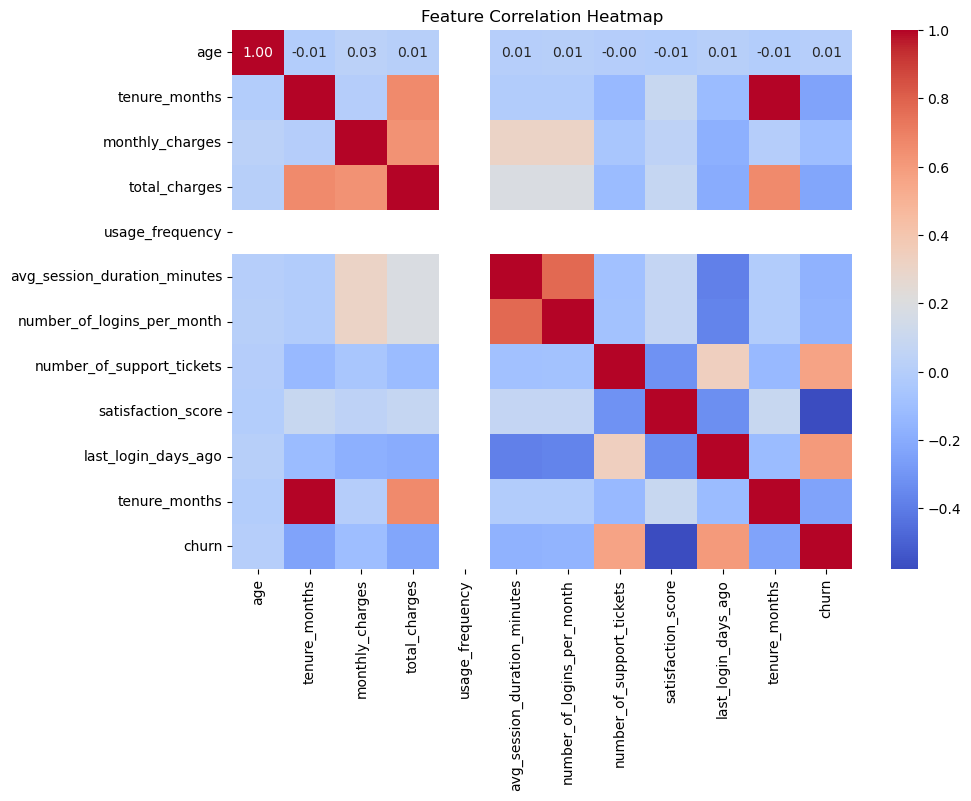

In [169]:
# Multivariate Analysis & Correlation (Correct)


# Define correct numerical features

numerical_features = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "usage_frequency",
    "avg_session_duration_minutes",
    "number_of_logins_per_month",
    "number_of_support_tickets",
    "satisfaction_score",
    "last_login_days_ago",
    "tenure_months",
    "churn"
]


# Create correlation dataframe

corr_df = df[numerical_features]


# Show correlation matrix (table)

correlation_matrix = corr_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)


##### Correlation Heatmap (Essential Graphic)


plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [171]:
# Correlation values range from -1 to +1
# +1 → strong positive relationship
# -1 → strong negative relationship
# 0 → no relationship

correlation_matrix = corr_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                                   age  tenure_months  monthly_charges  \
age                           1.000000      -0.009194         0.028310   
tenure_months                -0.009194       1.000000        -0.000998   
monthly_charges               0.028310      -0.000998         1.000000   
total_charges                 0.011781       0.662814         0.634164   
usage_frequency                    NaN            NaN              NaN   
avg_session_duration_minutes  0.007470      -0.012988         0.304315   
number_of_logins_per_month    0.008811      -0.010783         0.308904   
number_of_support_tickets    -0.002159      -0.131862        -0.058143   
satisfaction_score           -0.005927       0.091599         0.042608   
last_login_days_ago           0.013446      -0.119839        -0.177398   
tenure_months                -0.009194       1.000000        -0.000998   
churn                         0.006893      -0.239026        -0.107328   

                 

In [173]:
#shows which features are most related to churn

churn_correlation = correlation_matrix["churn"].sort_values(ascending=False)

print("\nFeature Correlation with Churn:")
print(churn_correlation)


Feature Correlation with Churn:
churn                           1.000000
last_login_days_ago             0.603591
number_of_support_tickets       0.564679
age                             0.006893
monthly_charges                -0.107328
number_of_logins_per_month     -0.160164
avg_session_duration_minutes   -0.167620
total_charges                  -0.226547
tenure_months                  -0.239026
tenure_months                  -0.239026
satisfaction_score             -0.577549
usage_frequency                      NaN
Name: churn, dtype: float64


C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


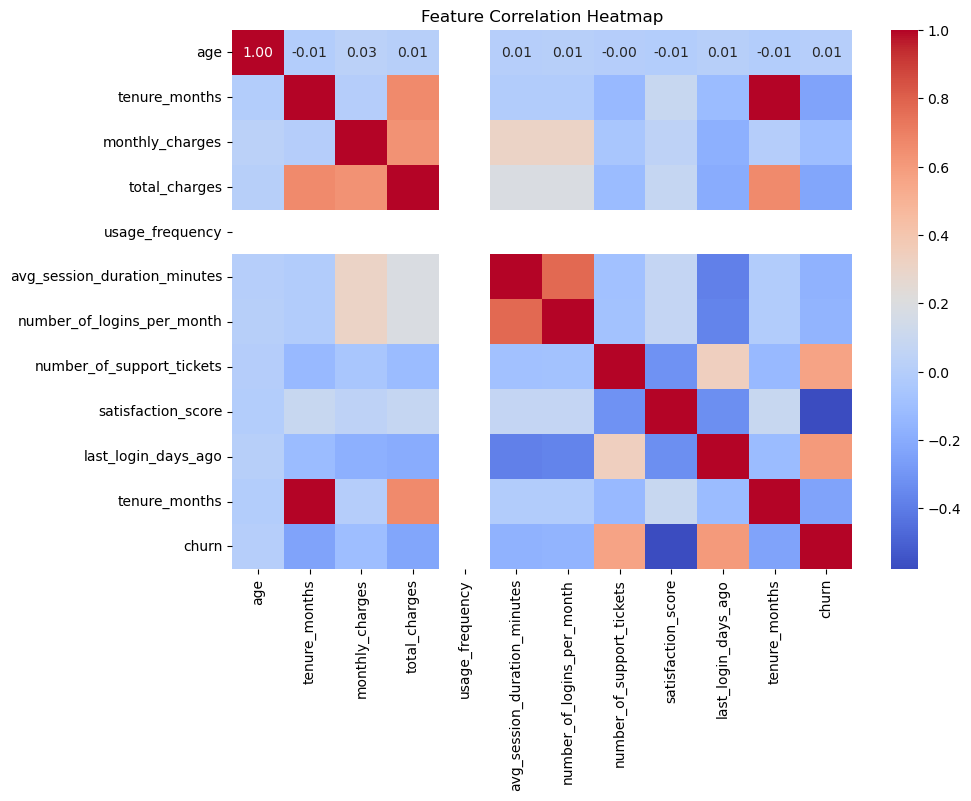

In [175]:
# Heatmap helps visually identify strong relationships

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,        # show correlation values
    cmap="coolwarm",   # color scheme
    fmt=".2f"          # show values with 2 decimal places
)

plt.title("Feature Correlation Heatmap")

plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


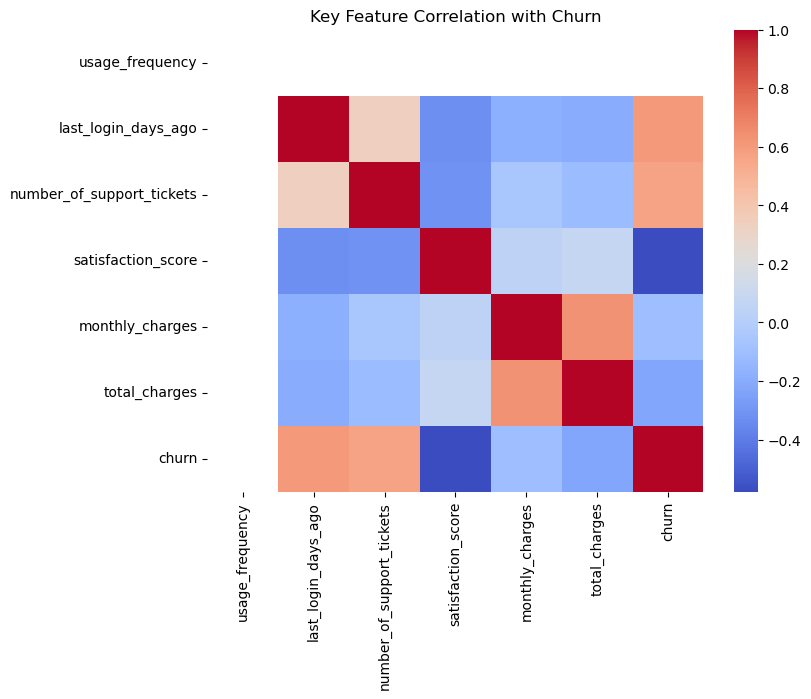

In [177]:
# Automatically select important churn-related features

key_features = [
    "usage_frequency",
    "last_login_days_ago",
    "number_of_support_tickets",
    "satisfaction_score",
    "monthly_charges",
    "total_charges",
    "churn"
]

# Create heatmap

plt.figure(figsize=(8,6))

sns.heatmap(df[key_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Key Feature Correlation with Churn")

plt.show()

In [ ]:
#Churn Risk Segmentation

In [179]:
# Churn Risk Segmentation (Correct)


# Initialize risk score

df["risk_score"] = 0


# Add risk if satisfaction is low (<= 2)

df.loc[df["satisfaction_score"] <= 2, "risk_score"] += 1


# Add risk if usage frequency is low (below median)

df.loc[
    df["usage_frequency"] < df["usage_frequency"].median(),
    "risk_score"
] += 1


# Add risk if customer inactive for long time

df.loc[
    df["last_login_days_ago"] > df["last_login_days_ago"].median(),
    "risk_score"
] += 1


# Show sample output

print(df[[
    "satisfaction_score",
    "usage_frequency",
    "last_login_days_ago",
    "risk_score"
]].head())

   satisfaction_score  usage_frequency  last_login_days_ago  risk_score
0                   5              NaN                    4           0
1                   3              NaN                   13           0
2                   5              NaN                   54           1
3                   3              NaN                    6           0
4                   5              NaN                   59           1


In [181]:
# Convert risk_score into risk levels

def risk_category(score):
    
    if score == 0:
        return "Low Risk"
    
    elif score == 1:
        return "Medium Risk"
    
    else:
        return "High Risk"


# Apply function to create risk segment
df["churn_risk_segment"] = df["risk_score"].apply(risk_category)


# Check distribution of risk segments
print("\nChurn Risk Segment Distribution:")
print(df["churn_risk_segment"].value_counts())


Churn Risk Segment Distribution:
churn_risk_segment
Low Risk       6438
Medium Risk    6016
High Risk      2546
Name: count, dtype: int64


In [183]:
#  Compare churn rate across risk segments (Important table)


risk_vs_churn = pd.crosstab(df["churn_risk_segment"], df["churn"])

print("\nChurn vs Risk Segment:")
print(risk_vs_churn)


Churn vs Risk Segment:
churn                  0     1
churn_risk_segment            
High Risk            255  2291
Low Risk            6103   335
Medium Risk         3859  2157


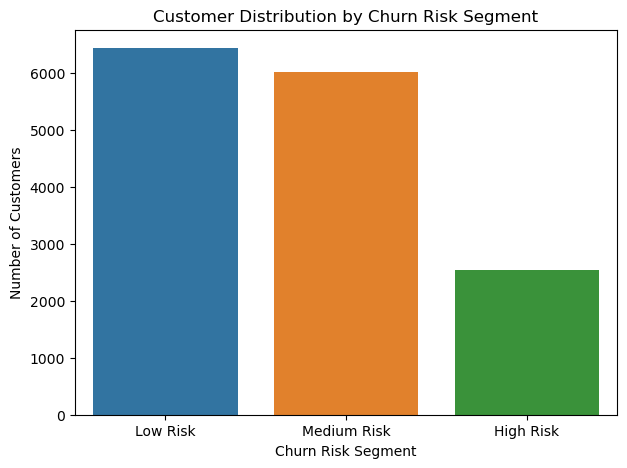

In [185]:
# This graph shows number of customers in each risk category

plt.figure(figsize=(7,5))

sns.countplot(x="churn_risk_segment", data=df, order=["Low Risk", "Medium Risk", "High Risk"])

plt.title("Customer Distribution by Churn Risk Segment")
plt.xlabel("Churn Risk Segment")
plt.ylabel("Number of Customers")

plt.show()

AttributeError: 'numpy.int64' object has no attribute 'startswith'

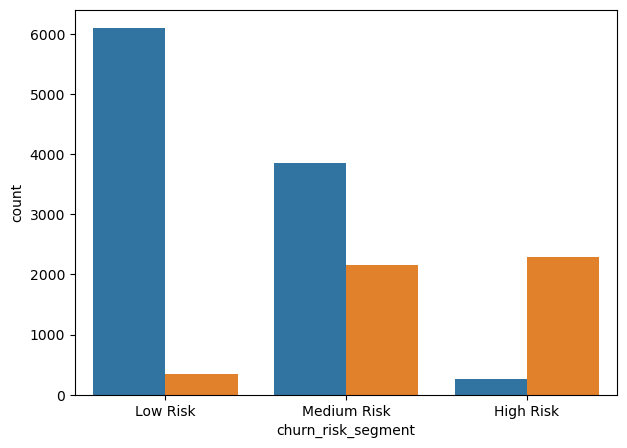

In [187]:
# This shows churn proportion within each risk group

plt.figure(figsize=(7,5))

sns.countplot(
    x="churn_risk_segment",
    hue="churn",
    data=df,
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Churn Rate by Risk Segment")
plt.xlabel("Churn Risk Segment")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
#Business Questions & Answers

In [ ]:
#Question 1

#How does customer satisfaction score affect churn probability?


Churn Rate by Satisfaction Score:
satisfaction_score
1    0.794661
2    0.728011
3    0.393228
4    0.079301
5    0.059088
Name: churn, dtype: float64


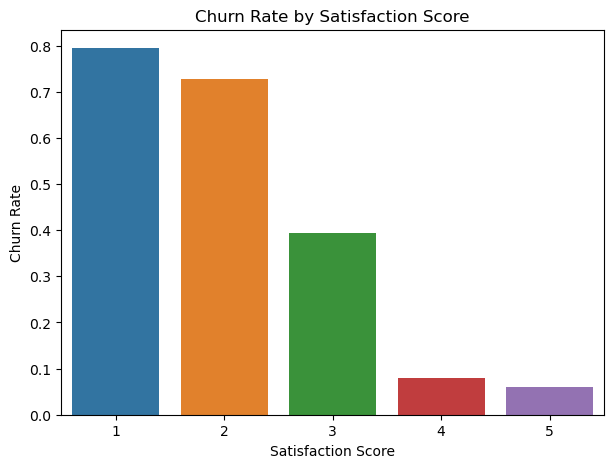

In [189]:
#Answer

# Group customers by satisfaction score and calculate churn rate

satisfaction_churn = df.groupby("satisfaction_score")["churn"].mean()

print("Churn Rate by Satisfaction Score:")
print(satisfaction_churn)


# Visualization to clearly see relationship

plt.figure(figsize=(7,5))

sns.barplot(x=satisfaction_churn.index, y=satisfaction_churn.values)

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate")

plt.show()

In [ ]:
#Question 2

#Does customer engagement (usage frequency) influence customer retention?

In [193]:
#Answer

# Clean dataframe before plotting




# Create clean copy of dataframe

df_plot = df.copy()

# Replace infinite values with NaN

df_plot = df_plot.replace([np.inf, -np.inf], np.nan)

# Convert columns to numeric (extra safety)

df_plot["usage_frequency"] = pd.to_numeric(df_plot["usage_frequency"], errors="coerce")
df_plot["churn"] = pd.to_numeric(df_plot["churn"], errors="coerce")

# Remove rows with missing values

df_plot = df_plot.dropna(subset=["usage_frequency", "churn"])



# Create boxplot safely


plt.figure(figsize=(7,5))

sns.boxplot(x="churn", y="usage_frequency", data=df_plot)

plt.title("Usage Frequency vs Churn")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Usage Frequency")

plt.show()

ValueError: min() arg is an empty sequence

<Figure size 700x500 with 0 Axes>

In [ ]:
#Question 3

#How does customer inactivity (last login days) impact churn risk?

In [195]:
#Answer

# Compare inactivity between retained and churned customers

inactivity_churn = df.groupby("churn")["last_login_days_ago"].mean()

print("Average Last Login Days by Churn:")
print(inactivity_churn)

Average Last Login Days by Churn:
churn
0    12.546540
1    41.404976
Name: last_login_days_ago, dtype: float64


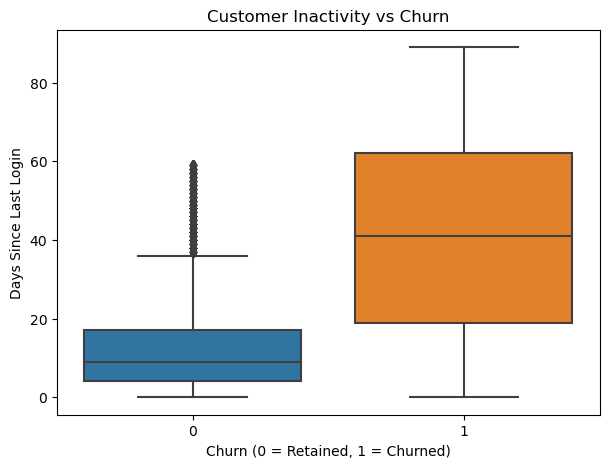

In [197]:
# Clean data before plotting



df_plot = df.replace([np.inf, -np.inf], np.nan)

df_plot = df_plot.dropna(subset=["churn", "last_login_days_ago"])


# Create boxplot

plt.figure(figsize=(7,5))

sns.boxplot(x="churn", y="last_login_days_ago", data=df_plot)

plt.title("Customer Inactivity vs Churn")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Days Since Last Login")

plt.show()

In [ ]:
#Question 4

#Which subscription type has the highest churn rate?

Churn Rate by Subscription Type:
subscription_type
basic       0.356876
premium     0.202840
standard    0.325692
Name: churn, dtype: float64


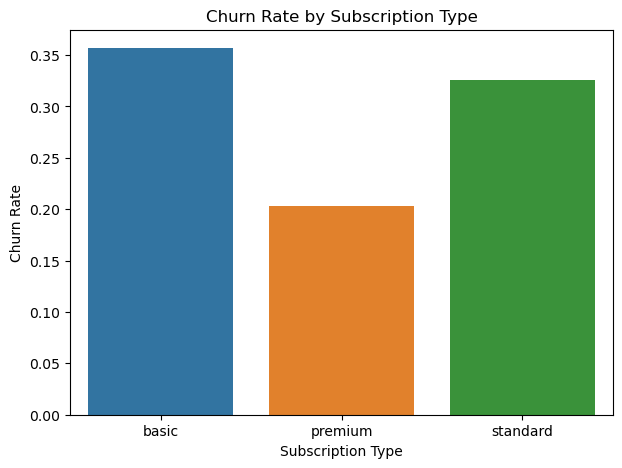

In [199]:
#Answer

# Calculate churn rate by subscription type

subscription_churn = df.groupby("subscription_type")["churn"].mean()

print("Churn Rate by Subscription Type:")
print(subscription_churn)


# Visualization

plt.figure(figsize=(7,5))

sns.barplot(x=subscription_churn.index, y=subscription_churn.values)

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate")

plt.show()

In [ ]:
#Question 5

#Do customers with more support tickets have higher churn?

In [201]:
# Support Tickets Impact on Churn (Correct)


# Compare average support tickets for retained vs churned customers

support_churn = df.groupby("churn")["number_of_support_tickets"].mean()

print("Average Support Tickets by Churn:")
print(support_churn)

Average Support Tickets by Churn:
churn
0    1.919154
1    5.080284
Name: number_of_support_tickets, dtype: float64


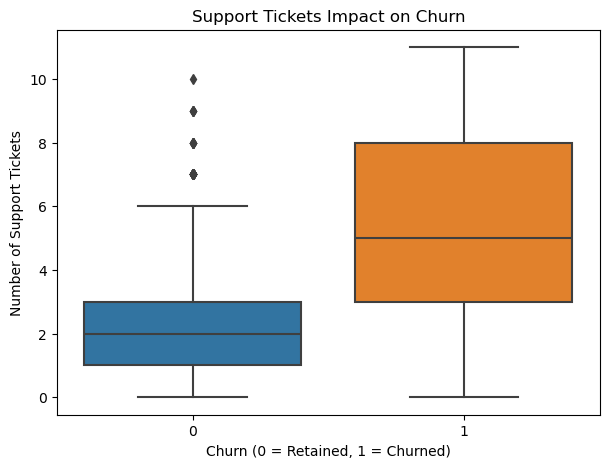

In [203]:
# Clean data before plotting


df_plot = df.replace([np.inf, -np.inf], np.nan)

df_plot = df_plot.dropna(subset=["churn", "number_of_support_tickets"])


# Create boxplot

plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn",
    y="number_of_support_tickets",
    data=df_plot
)

plt.title("Support Tickets Impact on Churn")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Support Tickets")

plt.show()


In [ ]:
#Question 6

#How do monthly charges influence churn?

Average Monthly Charges by Churn:
churn
0    61.469184
1    53.870366
Name: monthly_charges, dtype: float64


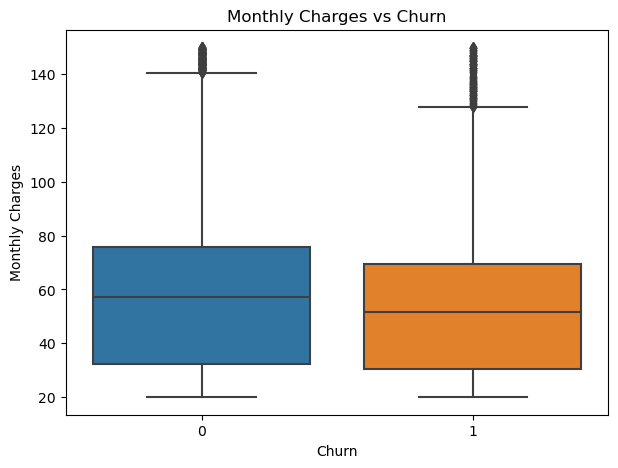

In [205]:
# Compare average monthly charges

charges_churn = df.groupby("churn")["monthly_charges"].mean()

print("Average Monthly Charges by Churn:")
print(charges_churn)


# Visualization

plt.figure(figsize=(7,5))

sns.boxplot(x="churn", y="monthly_charges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
#Question 7

#Do promotions and discounts improve retention?

Churn Rate by Promotional Response:
promotional_response
no     0.384308
yes    0.268646
Name: churn, dtype: float64


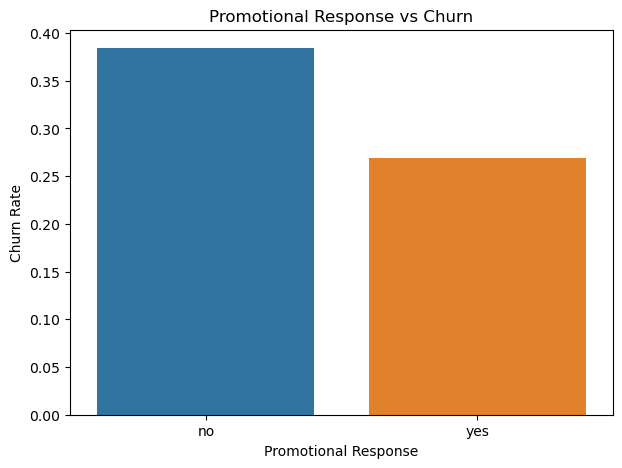

In [207]:
# Calculate churn rate based on promotional response

promo_churn = df.groupby("promotional_response")["churn"].mean()

print("Churn Rate by Promotional Response:")
print(promo_churn)


# Visualization

plt.figure(figsize=(7,5))

sns.barplot(x=promo_churn.index, y=promo_churn.values)

plt.title("Promotional Response vs Churn")
plt.xlabel("Promotional Response")
plt.ylabel("Churn Rate")

plt.show()